# Variant groups

comparing effect on variant groups

## General code

libraries and scripts

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import Markdown
import seaborn as sns
import os

# os.chdir("/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/ProximalPromoter/projects/inspect_variant_region_activity_HepG2")

## Analysis

In [3]:
df = pd.read_table('/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/standard_results/results/experiments/standard_bwa/variants/assignmentFixDuplicates/standardConfig/NGN2_variantTable.tsv.gz', sep='\t')
df = df.query('n_obs_bc_REF >=10 & n_obs_bc_ALT >=10')
display(df.head())
display(df.shape)


,ID,REF,ALT,dna_counts_REF,rna_counts_REF,dna_normalized_REF,rna_normalized_REF,ratio_REF,log2_REF,n_obs_bc_REF,dna_counts_ALT,rna_counts_ALT,dna_normalized_ALT,rna_normalized_ALT,ratio_ALT,log2_ALT,n_obs_bc_ALT,log2_expression
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,cardiac_neuro_cava_random:REF_AARS1|ENSG000000...,cardiac_neuro_cava_random:ALT_AARS1|ENSG000000...,550,1372,0.068486,0.074244,1.084085,0.116478,174,571,1300,0.075436,0.074638,0.989416,-0.015350,164,-0.131828
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,cardiac_neuro_cava_random:REF_AARS1|ENSG000000...,cardiac_neuro_cava_random:ALT_AARS1|ENSG000000...,246,538,0.069220,0.065788,0.950428,-0.073351,77,140,256,0.089214,0.070896,0.794665,-0.331582,34,-0.258231
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,cardiac_neuro_cava_random:REF_AARS1|ENSG000000...,cardiac_neuro_cava_random:ALT_AARS1|ENSG000000...,346,949,0.093707,0.111695,1.191961,0.253337,80,577,1399,0.066145,0.069697,1.053692,0.075454,189,-0.177883
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,cardiac_neuro_cava_random:REF_AARS1|ENSG000000...,cardiac_neuro_cava_random:ALT_AARS1|ENSG000000...,346,949,0.093707,0.111695,1.191961,0.253337,80,623,1785,0.062491,0.077811,1.245151,0.316321,216,0.062984
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,cardiac_neuro_cava_random:REF_AARS1|ENSG000000...,cardiac_neuro_cava_random:ALT_AARS1|ENSG000000...,346,949,0.093707,0.111695,1.191961,0.253337,80,679,1856,0.066870,0.079435,1.187901,0.248414,220,-0.004923


(41208, 18)

In [6]:
variants_neural = df[df['ID'].str.startswith('MPRAML_all_neutral_', na=False)]
variants_active = df[df['ID'].str.startswith(('MPRAML_all_positive_', 'MPRAML_HepG2_positive_'), na=False)]
variants_repressive = df[df['ID'].str.startswith(('MPRAML_all_negative_','MPRAML_HepG2_negative_'), na=False)]

In [7]:
print("#neutral:", len(variants_neural), "#active:", len(variants_active),"#repressive:",  len(variants_repressive))
print("mean neutral:",variants_neural["log2_expression"].mean(),"mean active:", variants_active["log2_expression"].mean(),"mean repressive:", variants_repressive["log2_expression"].mean())
display(Markdown("##ranksum active vs neutral, alt=greater"))
display(stats.ranksums(variants_active["log2_expression"],variants_neural["log2_expression"],alternative='greater'))
display(Markdown("##ranksum repressive vs neutral, alt=less"))
display(stats.ranksums(variants_repressive["log2_expression"],variants_neural["log2_expression"],alternative='less'))
display(Markdown("##ranksum repressive vs active, alt=less"))
display(stats.ranksums(variants_repressive["log2_expression"],variants_active["log2_expression"],alternative='less'))

#neutral: 0 #active: 0 #repressive: 0
mean neutral: nan mean active: nan mean repressive: nan


##ranksum active vs neutral, alt=greater

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/scipy/stats/_stats_py.py:9191: RuntimeWarning: invalid value encountered in scalar divide
  z = (s - expected) / np.sqrt(n1*n2*(n1+n2+1)/12.0)


RanksumsResult(statistic=nan, pvalue=nan)

##ranksum repressive vs neutral, alt=less

RanksumsResult(statistic=nan, pvalue=nan)

##ranksum repressive vs active, alt=less

RanksumsResult(statistic=nan, pvalue=nan)

In [8]:
display(Markdown("##kruskal wallis active vs neutral, alt=greater"))
display(stats.kruskal(variants_active["log2_expression"],variants_neural["log2_expression"]))
display(Markdown("##kruskal wallis  repressive vs neutral, alt=less"))
display(stats.kruskal(variants_repressive["log2_expression"],variants_neural["log2_expression"]))
display(Markdown("##kruskal wallis  repressive vs active, alt=less"))
display(stats.kruskal(variants_repressive["log2_expression"],variants_active["log2_expression"]))

##kruskal wallis active vs neutral, alt=greater

KruskalResult(statistic=nan, pvalue=nan)

##kruskal wallis  repressive vs neutral, alt=less

KruskalResult(statistic=nan, pvalue=nan)

##kruskal wallis  repressive vs active, alt=less

KruskalResult(statistic=nan, pvalue=nan)

In [9]:
display(Markdown("##Kolmogorov-Smirnov test active vs neutral, alt=greater"))
display(stats.kstest(variants_active["log2_expression"],variants_neural["log2_expression"]))
display(Markdown("##Kolmogorov-Smirnov test f  repressive vs neutral, alt=less"))
display(stats.kstest(variants_repressive["log2_expression"],variants_neural["log2_expression"]))
display(Markdown("##Kolmogorov-Smirnov test repressive vs active, alt=less"))
display(stats.kstest(variants_repressive["log2_expression"],variants_active["log2_expression"]))

##Kolmogorov-Smirnov test active vs neutral, alt=greater

ValueError: Data passed to ks_2samp must not be empty

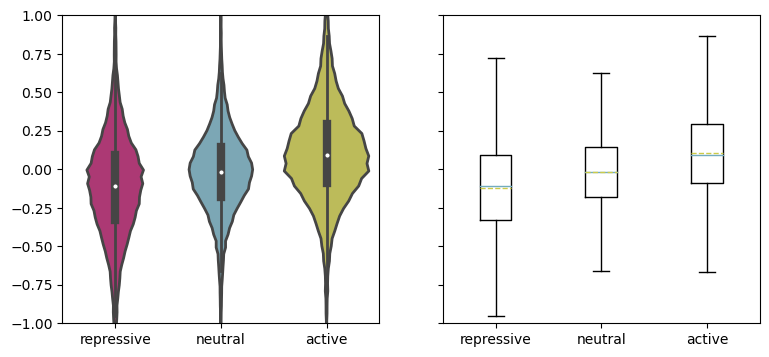

In [9]:


colors = ["#BF2675", "#72ACBF", "#CCCB4A"]
sns.set_palette(sns.color_palette(colors))

set_of_Columns = [variants_repressive["log2_expression"], variants_neural["log2_expression"], variants_active["log2_expression"]]
names = ["repressive", "neutral", "active"]
fig, (ax1, ax2)= plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharey=True)

sns.violinplot(set_of_Columns,ax=ax1, inner="box", scale="count", cut=0, bw=.03, linewidth=2,)
ax2.boxplot(set_of_Columns, showfliers=False,meanline=True, showmeans=True)

plt.ylim([-1, 1])

ax1.set_xticks([0,1,2])
ax1.set_xticklabels(names)
ax2.set_xticks([1,2,3])
ax2.set_xticklabels(names)
plt.show()

/tmp/ipykernel_11269/2979402674.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variants_repressive["Variant class"] = "repressive (n=%d)" % variants_repressive.shape[0]
/tmp/ipykernel_11269/2979402674.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variants_neural["Variant class"] = "neutral (n=%d)" % variants_neural.shape[0]
/tmp/ipykernel_11269/2979402674.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

(18890, 19)

(21227, 19)

(28224, 19)

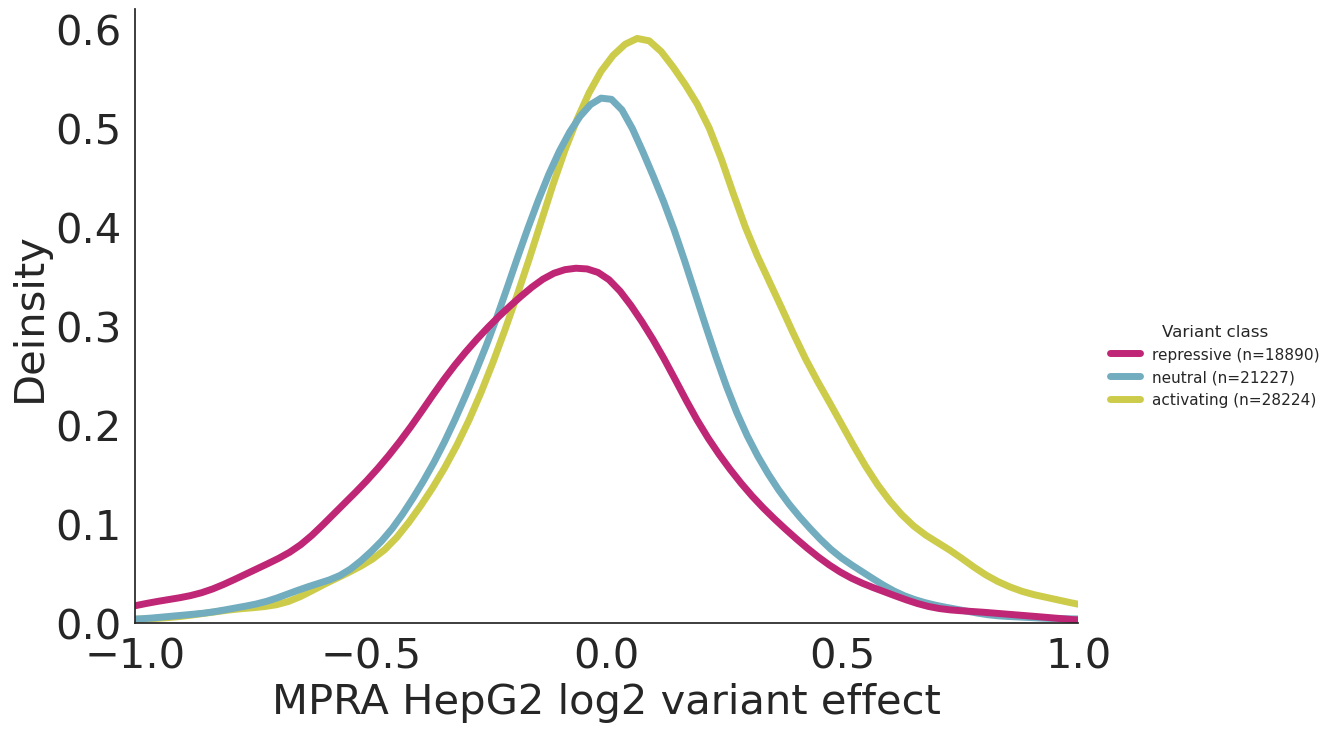

In [10]:
variants_repressive["Variant class"] = "repressive (n=%d)" % variants_repressive.shape[0]
variants_neural["Variant class"] = "neutral (n=%d)" % variants_neural.shape[0]
variants_active["Variant class"] = "activating (n=%d)" % variants_active.shape[0]
display(variants_repressive.shape,variants_neural.shape,variants_active.shape)
plot_df = pd.concat([variants_repressive, variants_neural, variants_active])


sns.set_theme(style='white')
colors = ["#BF2675", "#72ACBF", "#CCCB4A"]
sns.set_palette(sns.color_palette(colors))


g = sns.displot(plot_df, x= "log2_expression",  kind="kde", hue="Variant class", linewidth=5, height=7,aspect=1.5)
g.set_axis_labels("MPRA HepG2 log2 variant effect", "Density",fontsize=30)
#g.set_yticklabels(g.get_yticks(), size = 20)
g.set(xlim=(-1,1))
plt.tick_params(axis='both', which='major', labelsize=30)



g.figure.savefig("plots/HepG2_MPRA_variant_activity_density.png")
g.figure.savefig("plots/HepG2_MPRA_variant_activity_density.svg")
g.figure.savefig("plots/HepG2_MPRA_variant_activity_density.pdf")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


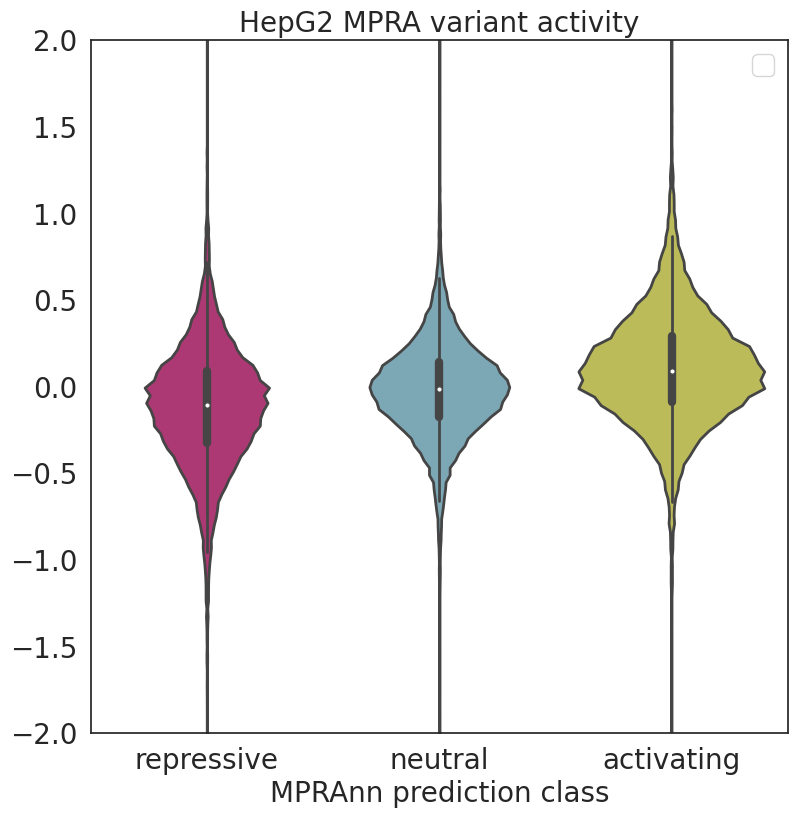

In [11]:


names = ["repressive", "neutral", "activating"]
fig, (ax1)= plt.subplots(nrows=1, figsize=(9, 9), sharey=True)

sns.violinplot(set_of_Columns,ax=ax1, inner="box", scale="count", cut=0, bw=.03, linewidth=2,)
ax2.boxplot(set_of_Columns, showfliers=False,meanline=True, showmeans=True)

#plt.ylim([-1, 1])

ax1.set_xticks([0,1,2])
ax1.set_xticklabels(names)

ax1.set_title("HepG2 MPRA variant activity", fontsize=20)
ax1.set_xlabel("MPRAnn prediction class")

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles[0:], labels=labels[0:])

ax1.yaxis.get_label().set_fontsize(20)
ax1.xaxis.get_label().set_fontsize(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)

plt.ylim([-2, 2])

plt.savefig("plots/HepG2_variant_activity_distribution_per_prediction_class.svg",dpi=300)
plt.savefig("plots/HepG2_variant_activity_distribution_per_prediction_class.pdf",dpi=300)
plt.savefig("plots/HepG2_variant_activity_distribution_per_prediction_class.png",dpi=300)

plt.show()

# Predicted variants

In [12]:
df_predicted = pd.read_table(
    '../../design/final_design/designed.predicted.tsv.gz',
    sep='\t')

df_predicted.head()


,#Chr,Pos,Ref,Alt,Region,region_id,strand,variant_id,Prediction_region,Position,...,AltPrediction_K562,Delta_HepG2,RefPrediction_HepG2,AltPrediction_HepG2,Delta_GM23248,RefPrediction_GM23248,AltPrediction_GM23248,Delta_iPS_DF_19_11,RefPrediction_iPS_DF_19_11,AltPrediction_iPS_DF_19_11
0,chr1,822969,A,T,chr1:822850-823049,Region_14,+,global_neutral_28459,chr1:822800-823099,169,...,0.519513,-0.007499,0.088006,0.080507,-0.003139,0.027037,0.023898,-0.008909,0.019743,0.010834
1,chr1,825042,C,T,chr1:824974-825173,Region_16,+,unique_K562_negative_4536,chr1:824924-825223,118,...,0.313589,0.094858,0.108858,0.203716,0.265685,0.150087,0.415772,0.271926,0.128494,0.400420
2,chr1,832341,G,C,chr1:832240-832439,Region_22,-,global_positive_14050,chr1:832489-832190,148,...,0.637246,0.373082,0.294885,0.667967,0.384568,0.523038,0.907607,0.484821,0.482615,0.967436
3,chr1,832343,G,C,chr1:832240-832439,Region_22,-,global_positive_15392,chr1:832489-832190,146,...,0.815491,0.330342,0.294885,0.625228,0.351257,0.523038,0.874296,0.433832,0.482615,0.916447
4,chr1,832344,G,C,chr1:832240-832439,Region_22,-,unique_HepG2_positive_rest_601702,chr1:832489-832190,145,...,0.449720,0.150811,0.294885,0.445696,-0.050133,0.523038,0.472906,-0.030412,0.482615,0.452203


In [13]:
df_predicted['ID'] = (
    "MPRAML_" + 
    df_predicted.variant_id.str.replace("rest_", "r").str.replace("global_","all_").str.replace("unique_","").str.replace(";.+","") +
    "_" + df_predicted['#Chr'] + ":" + df_predicted['Pos'].astype(str) + df_predicted['Ref'] + ">" + df_predicted['Alt']
)

/tmp/ipykernel_11269/3342920885.py:3: FutureWarning: The default value of regex will change from True to False in a future version.
  df_predicted.variant_id.str.replace("rest_", "r").str.replace("global_","all_").str.replace("unique_","").str.replace(";.+","") +


In [14]:
df_predicted.set_index('ID',inplace=True)
df_predicted.head()

,#Chr,Pos,Ref,Alt,Region,region_id,strand,variant_id,Prediction_region,Position,...,AltPrediction_K562,Delta_HepG2,RefPrediction_HepG2,AltPrediction_HepG2,Delta_GM23248,RefPrediction_GM23248,AltPrediction_GM23248,Delta_iPS_DF_19_11,RefPrediction_iPS_DF_19_11,AltPrediction_iPS_DF_19_11
ID,,,,,,,,,,,,,,,,,,,,,
MPRAML_all_neutral_28459_chr1:822969A>T,chr1,822969,A,T,chr1:822850-823049,Region_14,+,global_neutral_28459,chr1:822800-823099,169,...,0.519513,-0.007499,0.088006,0.080507,-0.003139,0.027037,0.023898,-0.008909,0.019743,0.010834
MPRAML_K562_negative_4536_chr1:825042C>T,chr1,825042,C,T,chr1:824974-825173,Region_16,+,unique_K562_negative_4536,chr1:824924-825223,118,...,0.313589,0.094858,0.108858,0.203716,0.265685,0.150087,0.415772,0.271926,0.128494,0.400420
MPRAML_all_positive_14050_chr1:832341G>C,chr1,832341,G,C,chr1:832240-832439,Region_22,-,global_positive_14050,chr1:832489-832190,148,...,0.637246,0.373082,0.294885,0.667967,0.384568,0.523038,0.907607,0.484821,0.482615,0.967436
MPRAML_all_positive_15392_chr1:832343G>C,chr1,832343,G,C,chr1:832240-832439,Region_22,-,global_positive_15392,chr1:832489-832190,146,...,0.815491,0.330342,0.294885,0.625228,0.351257,0.523038,0.874296,0.433832,0.482615,0.916447
MPRAML_HepG2_positive_r601702_chr1:832344G>C,chr1,832344,G,C,chr1:832240-832439,Region_22,-,unique_HepG2_positive_rest_601702,chr1:832489-832190,145,...,0.449720,0.150811,0.294885,0.445696,-0.050133,0.523038,0.472906,-0.030412,0.482615,0.452203


In [15]:
display(df.ID.str.startswith('MPRAML_', na=False).shape)

df_predicted_measured = df.set_index('ID').join(df_predicted, how='inner')
display(df_predicted_measured.head())
display(df_predicted_measured.shape)

(117579,)

,REF,ALT,dna_counts_REF,rna_counts_REF,dna_normalized_REF,rna_normalized_REF,ratio_REF,log2_REF,n_obs_bc_REF,dna_counts_ALT,...,AltPrediction_K562,Delta_HepG2,RefPrediction_HepG2,AltPrediction_HepG2,Delta_GM23248,RefPrediction_GM23248,AltPrediction_GM23248,Delta_iPS_DF_19_11,RefPrediction_iPS_DF_19_11,AltPrediction_iPS_DF_19_11
ID,,,,,,,,,,,,,,,,,,,,,
MPRAML_HEK293T_negative_1000_chr12:48197622G>T,oligo_051664,oligo_051665,425,936,0.022867,0.018185,0.795239,-0.330540,90,449,...,0.124555,0.019184,0.793374,0.812557,-0.120509,0.483887,0.363378,-0.073492,0.804908,0.731416
MPRAML_HEK293T_negative_1002_chr1:153665885C>A,oligo_020252,oligo_020253,103,150,0.015114,0.007948,0.525853,-0.927267,33,316,...,0.530901,0.007043,-0.012373,-0.005330,0.004855,0.017392,0.022247,0.007126,0.116360,0.123486
MPRAML_HEK293T_negative_1005_chr6:116287883G>C,oligo_180019,oligo_180020,193,368,0.020769,0.014299,0.688496,-0.538480,45,133,...,-0.035620,-0.556714,0.598815,0.042101,-0.284164,0.768115,0.483950,-0.190945,0.925478,0.734533
MPRAML_HEK293T_negative_1006_chr1:16032978C>G,oligo_009427,oligo_009428,939,5207,0.017422,0.034883,2.002316,1.001670,261,747,...,0.828887,-0.122753,0.601766,0.479012,-0.045148,0.840738,0.795589,-0.054086,0.863317,0.809231
MPRAML_HEK293T_negative_1008_chr16:72018785C>G,oligo_082786,oligo_082787,239,451,0.015431,0.010514,0.681380,-0.553469,75,420,...,0.030737,0.008974,0.087649,0.096623,-0.081073,0.078546,-0.002527,-0.171087,0.225965,0.054878


(113732, 43)

<AxesSubplot: xlabel='Delta_HepG2', ylabel='log2_expression'>

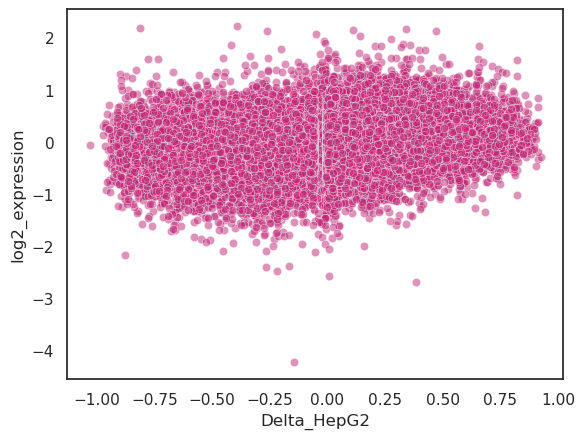

In [16]:
sns.scatterplot(data=df_predicted_measured, x="Delta_HepG2", y="log2_expression", alpha=0.5)


<AxesSubplot: xlabel='Delta_HepG2_abs', ylabel='log2_expression_abs'>

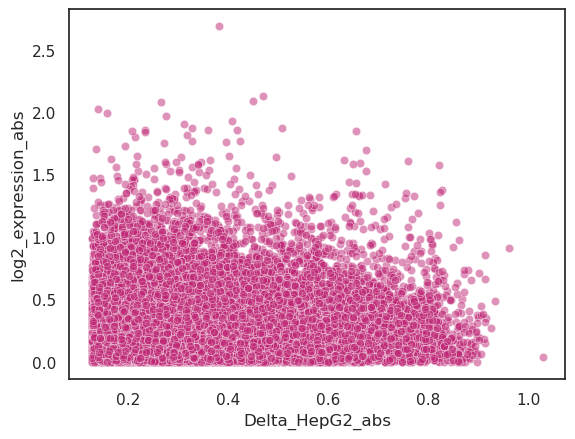

In [17]:
import numpy as np
df_predicted_measured["Delta_HepG2_abs"] = np.abs(df_predicted_measured['Delta_HepG2'])
df_predicted_measured["log2_expression_abs"] = np.abs(df_predicted_measured['log2_expression'])
sns.scatterplot(data=df_predicted_measured[df_predicted_measured.index.str.startswith(('MPRAML_all_positive_', 'MPRAML_HepG2_positive_', 'MPRAML_HepG2_negative_'), na=False)], x="Delta_HepG2_abs", y="log2_expression_abs", alpha=0.5) 




<AxesSubplot: xlabel='Delta_HepG2_abs', ylabel='log2_expression'>

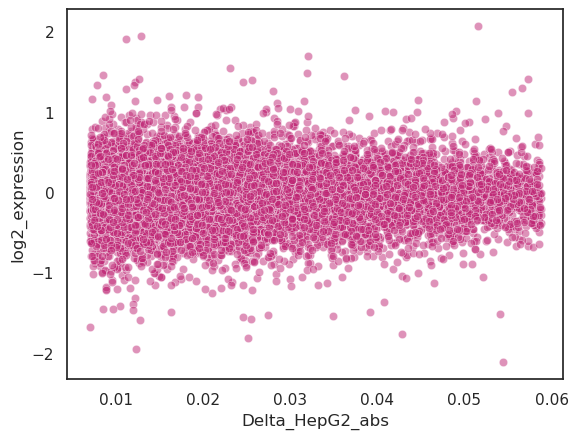

In [18]:
sns.scatterplot(data=df_predicted_measured[df_predicted_measured.index.str.startswith(('MPRAML_all_neutral_'), na=False)], x="Delta_HepG2_abs", y="log2_expression", alpha=0.5) 



/tmp/ipykernel_11269/1709056936.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["class"] = "neutral"
/tmp/ipykernel_11269/1709056936.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot_tmp["class"] = "activating/repressing"


(-2.0, 2.0)

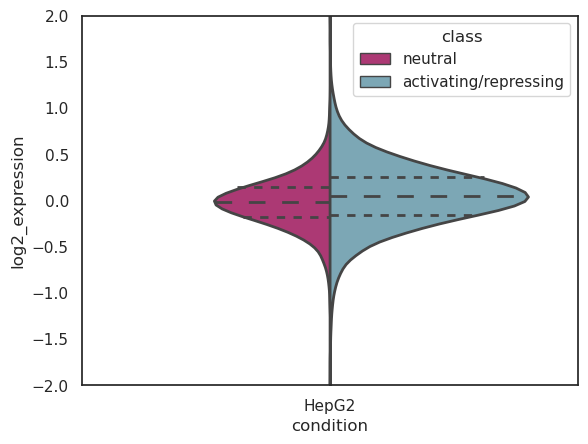

In [19]:

df_plot = df_predicted_measured[df_predicted_measured.index.str.startswith(('MPRAML_all_neutral_'), na=False)]
df_plot["class"] = "neutral"
df_plot_tmp = df_predicted_measured[df_predicted_measured.index.str.startswith(('MPRAML_all_positive_', 'MPRAML_HepG2_positive_', 'MPRAML_HepG2_negative_'), na=False)]
df_plot_tmp["class"] = "activating/repressing"

df_plot = pd.concat([df_plot, df_plot_tmp])
df_plot["condition"] = "HepG2"

sns.violinplot(data=df_plot, y="log2_expression", x="condition", hue="class", split=True,
               inner="quartile", scale="count", cut=0, bw=.2, linewidth=2)

plt.ylim([-2, 2])

# MPRAnn retrained

In [20]:
df_retrained_map = pd.read_table(
    '../../experiments/first_approach/MPRAsnakeflow/inputs/MPRAML/variants/oligomap.tsv.gz',
    sep='\t')

df_retrained_map[df_retrained_map.ID.isin(["MPRAML_K562_positive_2825_chr9:129275727T>G"])]


,ID,REF,ALT
170850,MPRAML_K562_positive_2825_chr9:129275727T>G,oligo_205970,oligo_205971


In [21]:
df_retrained_prediction = pd.read_table(
    '../retraining_on_MPRA_expression/regression_hepG2/activity/results/test_predictions/predictions/finalMeanLabels.proximalPromoter_HepG2_all.tsv.gz',
    sep='\t',usecols=["ID","HepG2_actvity.MEAN_prediction"])
df_retrained_prediction[df_retrained_prediction.ID.isin(["oligo_000002","oligo_005265"])]

,ID,HepG2_actvity.MEAN_prediction
0,oligo_000002,0.048393
4834,oligo_005265,0.242588


In [22]:
df_retrained_prediction_final = df_retrained_map.rename(columns={"REF":"REF_ID"}
                      ).set_index("REF_ID").join(
                      df_retrained_prediction.rename(
                          columns={"ID":"REF_ID","HepG2_actvity.MEAN_prediction":"REF_prediction"}
                      ).set_index("REF_ID"),how="left").rename(columns={"ALT":"ALT_ID"}).set_index("ALT_ID").join(
df_retrained_prediction.rename(
                          columns={"ID":"ALT_ID","HepG2_actvity.MEAN_prediction":"ALT_prediction"}
                      ).set_index("ALT_ID"),how="left"
)
df_retrained_prediction_final.shape

(177048, 3)

In [23]:
df_retrained_prediction_final["MPRAnn"] = df_retrained_prediction_final["ALT_prediction"] - df_retrained_prediction_final["REF_prediction"]
df_retrained_prediction_final.head()

,ID,REF_prediction,ALT_prediction,MPRAnn
ALT_ID,,,,
oligo_002742,SaturationMutagenesis_LDLR_75_C.T_chr19:110892...,NaN,0.131713,NaN
oligo_002743,SaturationMutagenesis_LDLR_76_T.C_chr19:110892...,NaN,0.111029,NaN
oligo_002744,SaturationMutagenesis_LDLR_81_A.G_chr19:110892...,NaN,0.134801,NaN
oligo_002745,SaturationMutagenesis_LDLR_83_G.A_chr19:110892...,NaN,0.148975,NaN
oligo_002746,SaturationMutagenesis_LDLR_84_G.A_chr19:110892...,NaN,0.123213,NaN


In [24]:
df_retrained = df_predicted_measured.join(df_retrained_prediction_final.set_index("ID"), how="inner")

In [25]:
# something not corrct in the join
df_retrained.shape

(113732, 48)

<AxesSubplot: xlabel='MPRAnn', ylabel='log2_expression'>

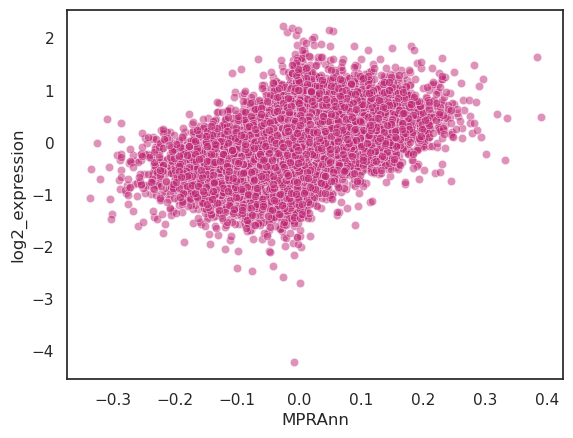

In [26]:
sns.scatterplot(data=df_retrained, x="MPRAnn", y="log2_expression", alpha=0.5) 



In [27]:
df_retrained.to_csv('data/mpra_variant_activity_mprann_retrained.tsv.gz', sep="\t")

# retrain_all

,ID,HepG2_activity_MPRAnn
0,oligo_000002,-0.144015
1,oligo_000003,0.455881
2,oligo_000004,-0.447439
3,oligo_000005,0.773548
4,oligo_000006,0.111327
...,...,...
206725,oligo_243994,0.572481
206726,oligo_243996,0.122759
206727,oligo_243997,-0.232845
206728,oligo_243999,-0.199219


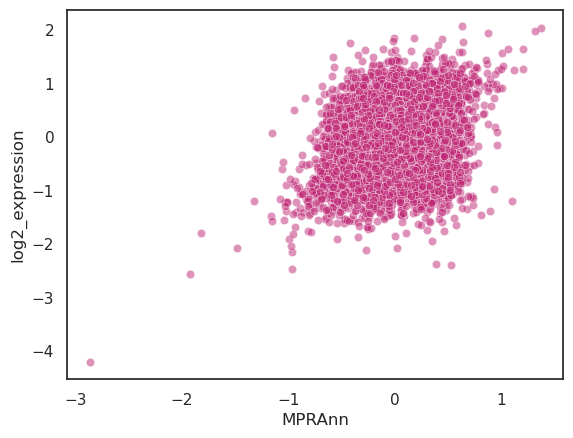

In [28]:
df_retrained_prediction = pd.read_table(
    '../retraining_on_MPRA_expression/regression_hepG2/activity_all/results/predictions/finalConcat.labels.cleaned.tsv.gz',
    sep='\t',usecols=["ID","HepG2_activity_MPRAnn"])
display(df_retrained_prediction)
df_retrained_prediction_final = df_retrained_map.rename(columns={"REF":"REF_ID"}
                      ).set_index("REF_ID").join(
                      df_retrained_prediction.rename(
                          columns={"ID":"REF_ID","HepG2_activity_MPRAnn":"REF_prediction"}
                      ).set_index("REF_ID"),how="left").rename(columns={"ALT":"ALT_ID"}).set_index("ALT_ID").join(
df_retrained_prediction.rename(
                          columns={"ID":"ALT_ID","HepG2_activity_MPRAnn":"ALT_prediction"}
                      ).set_index("ALT_ID"),how="left"
)
df_retrained_prediction_final["MPRAnn"] = df_retrained_prediction_final["REF_prediction"] - df_retrained_prediction_final["ALT_prediction"]

df_retrained = df_predicted_measured.join(df_retrained_prediction_final.set_index("ID"), how="inner")

sns.scatterplot(data=df_retrained, x="MPRAnn", y="log2_expression", alpha=0.5) 

df_retrained.to_csv('data/mpra_variant_activity_mprann_mpraultra_all.tsv.gz', sep="\t")


# MPRA_ultra

,ID,HepG2_activity.MEAN_prediction
0,oligo_000002,0.674442
1,oligo_000003,0.542050
2,oligo_000004,-0.068649
3,oligo_000005,0.800652
4,oligo_000006,0.391770
...,...,...
216435,oligo_243994,0.271602
216436,oligo_243996,-0.014847
216437,oligo_243997,-0.080410
216438,oligo_243999,0.068575


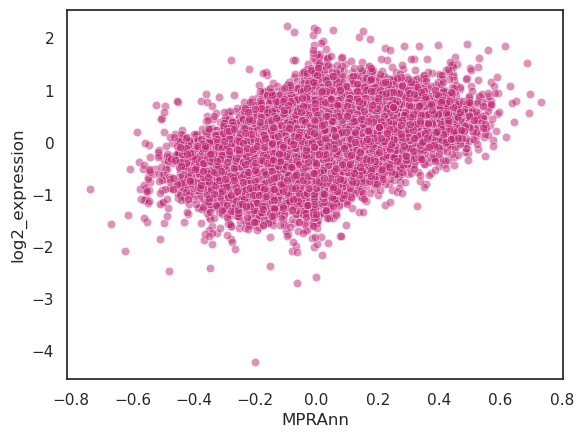

In [29]:
df_retrained_prediction = pd.read_table(
    '../retraining_on_MPRA_expression/MPRAUltra/results/test_predictions/predictions/finalMeanLabels.proximalPromoter_HepG2_all_all.tsv.gz',
    sep='\t',usecols=["ID","HepG2_activity.MEAN_prediction"])
display(df_retrained_prediction)
df_retrained_prediction_final = df_retrained_map.rename(columns={"REF":"REF_ID"}
                      ).set_index("REF_ID").join(
                      df_retrained_prediction.rename(
                          columns={"ID":"REF_ID","HepG2_activity.MEAN_prediction":"REF_prediction"}
                      ).set_index("REF_ID"),how="left").rename(columns={"ALT":"ALT_ID"}).set_index("ALT_ID").join(
df_retrained_prediction.rename(
                          columns={"ID":"ALT_ID","HepG2_activity.MEAN_prediction":"ALT_prediction"}
                      ).set_index("ALT_ID"),how="left"
)
df_retrained_prediction_final["MPRAnn"] = df_retrained_prediction_final["ALT_prediction"] - df_retrained_prediction_final["REF_prediction"]

df_retrained = df_predicted_measured.join(df_retrained_prediction_final.set_index("ID"), how="inner")

sns.scatterplot(data=df_retrained, x="MPRAnn", y="log2_expression", alpha=0.5) 

df_retrained.to_csv('data/mpra_variant_activity_mprann_ultra_all.tsv.gz', sep="\t")


# Enformer variants

In [30]:
df_enformer = pd.read_table(
    '../proximal_prom_analysis/predictions/enformer/prom_prox_enformer_pred.tsv.gz',
    sep='\t',usecols = [0,1,2,3,4,32,96,239])
df_enformer.head()

,chrom,pos,id,ref,alt,27_DNASE:HepG2,91_DNASE:HepG2,234_DNASE:HepG2
0,chr1,822969,Region14,A,T,0.098974,1.554286,0.984335
1,chr1,825042,Region16,C,T,0.158725,6.220351,0.819659
2,chr1,832341,Region22,G,C,14.252490,-97.390680,8.952026
3,chr1,832343,Region22,G,C,0.947449,-55.629475,-11.166438
4,chr1,832344,Region22,G,C,-2.719780,-1.752381,-1.269238


In [31]:
df_enformer['variant'] = df_enformer['chrom'] + ":" + df_enformer['pos'].astype(str) + df_enformer["ref"] + ">" + df_enformer["alt"]
df_enformer.drop(columns=['pos'],inplace=True)
df_enformer['Enformer'] = df_enformer.mean(numeric_only=True, axis=1)

df_enformer.head()

,chrom,id,ref,alt,27_DNASE:HepG2,91_DNASE:HepG2,234_DNASE:HepG2,variant,Enformer
0,chr1,Region14,A,T,0.098974,1.554286,0.984335,chr1:822969A>T,0.879198
1,chr1,Region16,C,T,0.158725,6.220351,0.819659,chr1:825042C>T,2.399578
2,chr1,Region22,G,C,14.252490,-97.390680,8.952026,chr1:832341G>C,-24.728721
3,chr1,Region22,G,C,0.947449,-55.629475,-11.166438,chr1:832343G>C,-21.949488
4,chr1,Region22,G,C,-2.719780,-1.752381,-1.269238,chr1:832344G>C,-1.913800


In [32]:
df_predicted_measured['variant'] = df_predicted_measured.index.str.replace("MPRAML_.+_r?\d+_","")
df_predicted_measured.head()

/tmp/ipykernel_11269/3254189834.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df_predicted_measured['variant'] = df_predicted_measured.index.str.replace("MPRAML_.+_r?\d+_","")


,REF,ALT,dna_counts_REF,rna_counts_REF,dna_normalized_REF,rna_normalized_REF,ratio_REF,log2_REF,n_obs_bc_REF,dna_counts_ALT,...,AltPrediction_HepG2,Delta_GM23248,RefPrediction_GM23248,AltPrediction_GM23248,Delta_iPS_DF_19_11,RefPrediction_iPS_DF_19_11,AltPrediction_iPS_DF_19_11,Delta_HepG2_abs,log2_expression_abs,variant
ID,,,,,,,,,,,,,,,,,,,,,
MPRAML_HEK293T_negative_1000_chr12:48197622G>T,oligo_051664,oligo_051665,425,936,0.022867,0.018185,0.795239,-0.330540,90,449,...,0.812557,-0.120509,0.483887,0.363378,-0.073492,0.804908,0.731416,0.019184,0.214908,chr12:48197622G>T
MPRAML_HEK293T_negative_1002_chr1:153665885C>A,oligo_020252,oligo_020253,103,150,0.015114,0.007948,0.525853,-0.927267,33,316,...,-0.005330,0.004855,0.017392,0.022247,0.007126,0.116360,0.123486,0.007043,0.010049,chr1:153665885C>A
MPRAML_HEK293T_negative_1005_chr6:116287883G>C,oligo_180019,oligo_180020,193,368,0.020769,0.014299,0.688496,-0.538480,45,133,...,0.042101,-0.284164,0.768115,0.483950,-0.190945,0.925478,0.734533,0.556714,0.158271,chr6:116287883G>C
MPRAML_HEK293T_negative_1006_chr1:16032978C>G,oligo_009427,oligo_009428,939,5207,0.017422,0.034883,2.002316,1.001670,261,747,...,0.479012,-0.045148,0.840738,0.795589,-0.054086,0.863317,0.809231,0.122753,0.293839,chr1:16032978C>G
MPRAML_HEK293T_negative_1008_chr16:72018785C>G,oligo_082786,oligo_082787,239,451,0.015431,0.010514,0.681380,-0.553469,75,420,...,0.096623,-0.081073,0.078546,-0.002527,-0.171087,0.225965,0.054878,0.008974,0.194596,chr16:72018785C>G


In [33]:
df_enformer_plot = df_enformer.set_index("variant").join(df_predicted_measured.set_index("variant"),how="inner")
df_enformer_plot.head()

,chrom,id,ref,alt,27_DNASE:HepG2,91_DNASE:HepG2,234_DNASE:HepG2,Enformer,REF,ALT,...,RefPrediction_HepG2,AltPrediction_HepG2,Delta_GM23248,RefPrediction_GM23248,AltPrediction_GM23248,Delta_iPS_DF_19_11,RefPrediction_iPS_DF_19_11,AltPrediction_iPS_DF_19_11,Delta_HepG2_abs,log2_expression_abs
variant,,,,,,,,,,,,,,,,,,,,,
chr10:100095367A>C,chr10,Region27740,A,C,-11.385016,-13.964912,-10.338359,-11.896096,oligo_033922,oligo_033924,...,0.609842,0.139476,0.051427,0.101122,0.152549,0.080102,0.192493,0.272594,0.470366,0.130291
chr10:100095368T>A,chr10,Region27740,T,A,-3.127317,-4.814837,-4.316037,-4.086064,oligo_033922,oligo_230916,...,0.609842,0.297479,0.052424,0.101122,0.153545,0.056651,0.192493,0.249143,0.312363,0.068503
chr10:100095372A>C,chr10,Region27740,A,C,-9.483684,-10.065965,-6.042687,-8.530779,oligo_033922,oligo_033923,...,0.609842,0.135990,0.013175,0.101122,0.114297,0.036107,0.192493,0.228600,0.473852,0.620450
chr10:100100729A>G,chr10,Region27741,A,G,21.753640,1.991378,-33.180733,-3.145238,oligo_033925,oligo_033927,...,0.292353,0.675974,0.182129,0.747528,0.929657,0.425608,0.514216,0.939824,0.383620,0.242518
chr10:100100740C>G,chr10,Region27741,C,G,15.307798,9.140451,-20.912080,1.178723,oligo_033925,oligo_033926,...,0.292353,0.737473,0.154279,0.747528,0.901807,0.408141,0.514216,0.922357,0.445120,0.124926


<AxesSubplot: xlabel='Enformer', ylabel='log2_expression'>

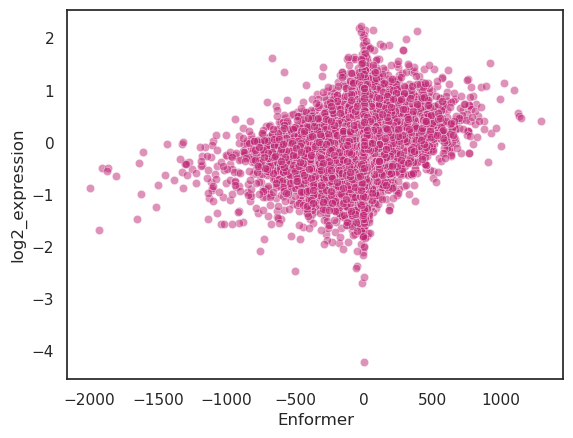

In [34]:
sns.scatterplot(data=df_enformer_plot, x="Enformer", y="log2_expression", alpha=0.5) 

In [35]:
df_enformer_plot.to_csv('data/mpra_variant_activity_enformer.tsv.gz', sep="\t")